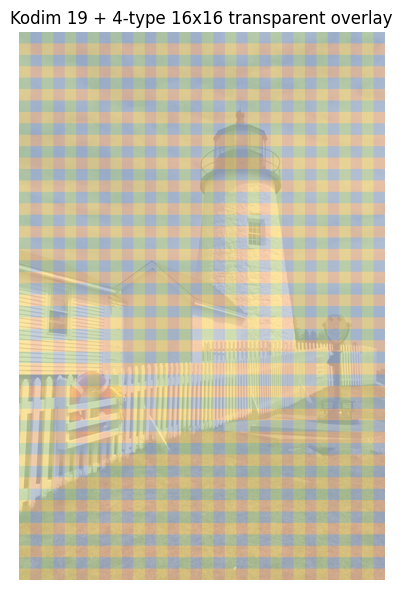

In [19]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Locate repo root by finding the datasets folder.
REPO_ROOT = Path().resolve()
while REPO_ROOT.name and not (REPO_ROOT / "datasets").exists():
    REPO_ROOT = REPO_ROOT.parent

img_path = REPO_ROOT / "datasets" / "kodak" / "kodim19.png"

# --- Checkerboard settings ---
block = 16  # 16x16 squares

# 4 tile types arranged as:
# 1,2,1,2,...
# 3,4,3,4,...
# 1,2,1,2,...
# ...
# Colors are RGBA in [0, 1].
# RGB comes from these hex values:
# type 1: #c5e0b4
# type 2: #b4c7e7
# type 3: #ffe699
# type 4: #f8cbad
transparency_alpha = 0.75
colors = np.array([
    [197 / 255, 224 / 255, 180 / 255, transparency_alpha],  # type 1
    [180 / 255, 199 / 255, 231 / 255, transparency_alpha],  # type 2
    [255 / 255, 230 / 255, 153 / 255, transparency_alpha],  # type 3
    [248 / 255, 203 / 255, 173 / 255, transparency_alpha],  # type 4
], dtype=np.float32)

# Load image
img = np.array(Image.open(img_path).convert("RGB"), dtype=np.uint8)
H, W = img.shape[:2]

# Compute block-row/block-col indices for each pixel
yy, xx = np.indices((H, W))
row_block = yy // block
col_block = xx // block

# Map each block to one of 4 types according to the requested 2x2 repeating pattern
# top row:    1,2,1,2,...  -> indices 0,1,0,1,...
# second row: 3,4,3,4,...  -> indices 2,3,2,3,...
tile_idx = (row_block % 2) * 2 + (col_block % 2)  # values in {0,1,2,3}

# Build per-pixel RGBA overlay
overlay = colors[tile_idx]  # shape (H, W, 4)

# Alpha blend overlay over image: out = (1-a)*img + a*color
img_f = img.astype(np.float32) / 255.0
a = overlay[..., 3:4]
out = (1.0 - a) * img_f + a * overlay[..., :3]

# Show side by side
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

ax.imshow(out)
ax.set_title("Kodim 19 + 4-type 16x16 transparent overlay")
ax.axis("off")

plt.tight_layout()
plt.show()

#c5e0b4
#b4c7e7
#ffe699
#f8cbad

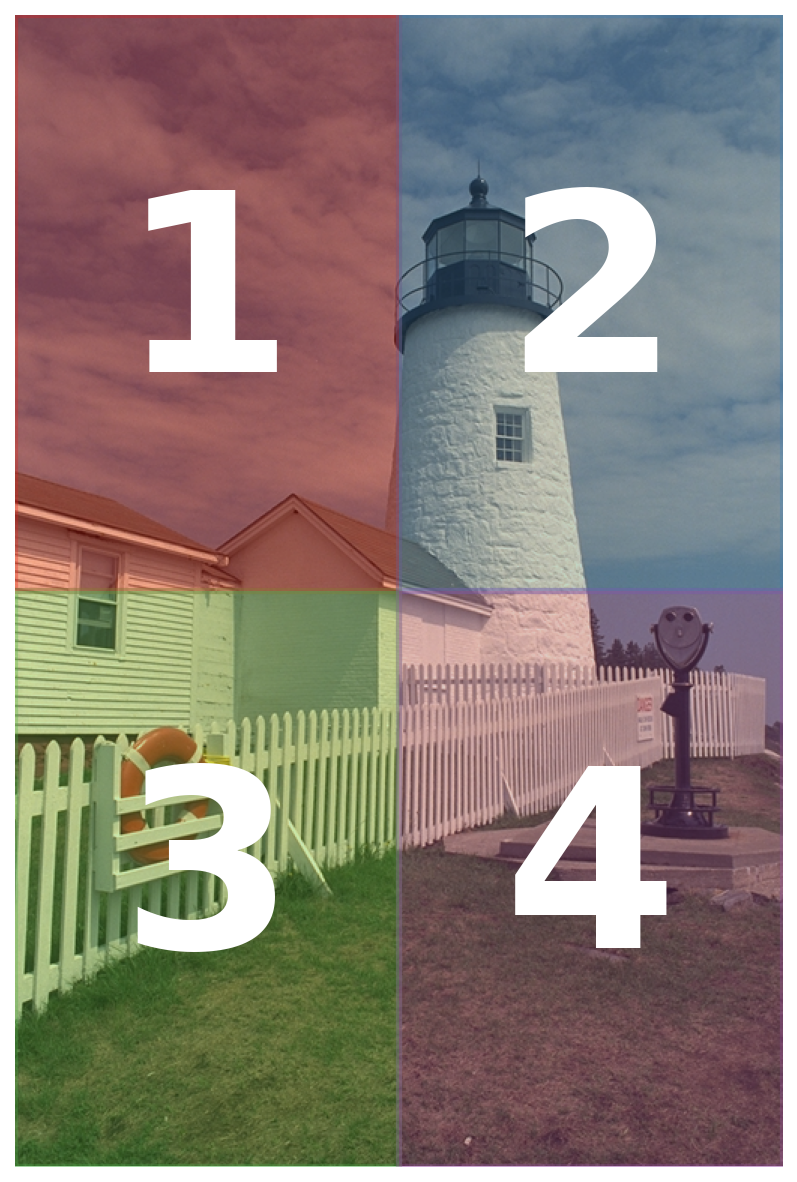

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from PIL import Image

REPO_ROOT = Path().resolve()
while REPO_ROOT.name and not (REPO_ROOT / "datasets").exists():
    REPO_ROOT = REPO_ROOT.parent

img_path = REPO_ROOT / "datasets" / "kodak" / "kodim19.png"
img = np.array(Image.open(img_path))
H, W = img.shape[:2]
hH, hW = H // 2, W // 2

quadrants = [
    {"label": "1", "xy": (0, 0),   "w": hW,      "h": hH,      "color": "#e41a1c"},
    {"label": "2", "xy": (hW, 0),  "w": W - hW,  "h": hH,      "color": "#377eb8"},
    {"label": "3", "xy": (0, hH),  "w": hW,      "h": H - hH,  "color": "#4daf4a"},
    {"label": "4", "xy": (hW, hH), "w": W - hW,  "h": H - hH,  "color": "#984ea3"},
]

fig, ax = plt.subplots(figsize=(W / 100, H / 100), dpi=150)
ax.imshow(img)
ax.set_axis_off()

for q in quadrants:
    ax.add_patch(
        Rectangle(q["xy"], q["w"], q["h"],
                  facecolor=q["color"], alpha=0.30,
                  edgecolor=q["color"], linewidth=3)
    )
    cx = q["xy"][0] + q["w"] / 2
    cy = q["xy"][1] + q["h"] / 2
    ax.text(cx, cy, q["label"],
            color="white", fontsize=120, fontweight="bold",
            ha="center", va="center")

ax.set_xlim(0, W)
ax.set_ylim(H, 0)
plt.tight_layout(pad=0)
plt.show()


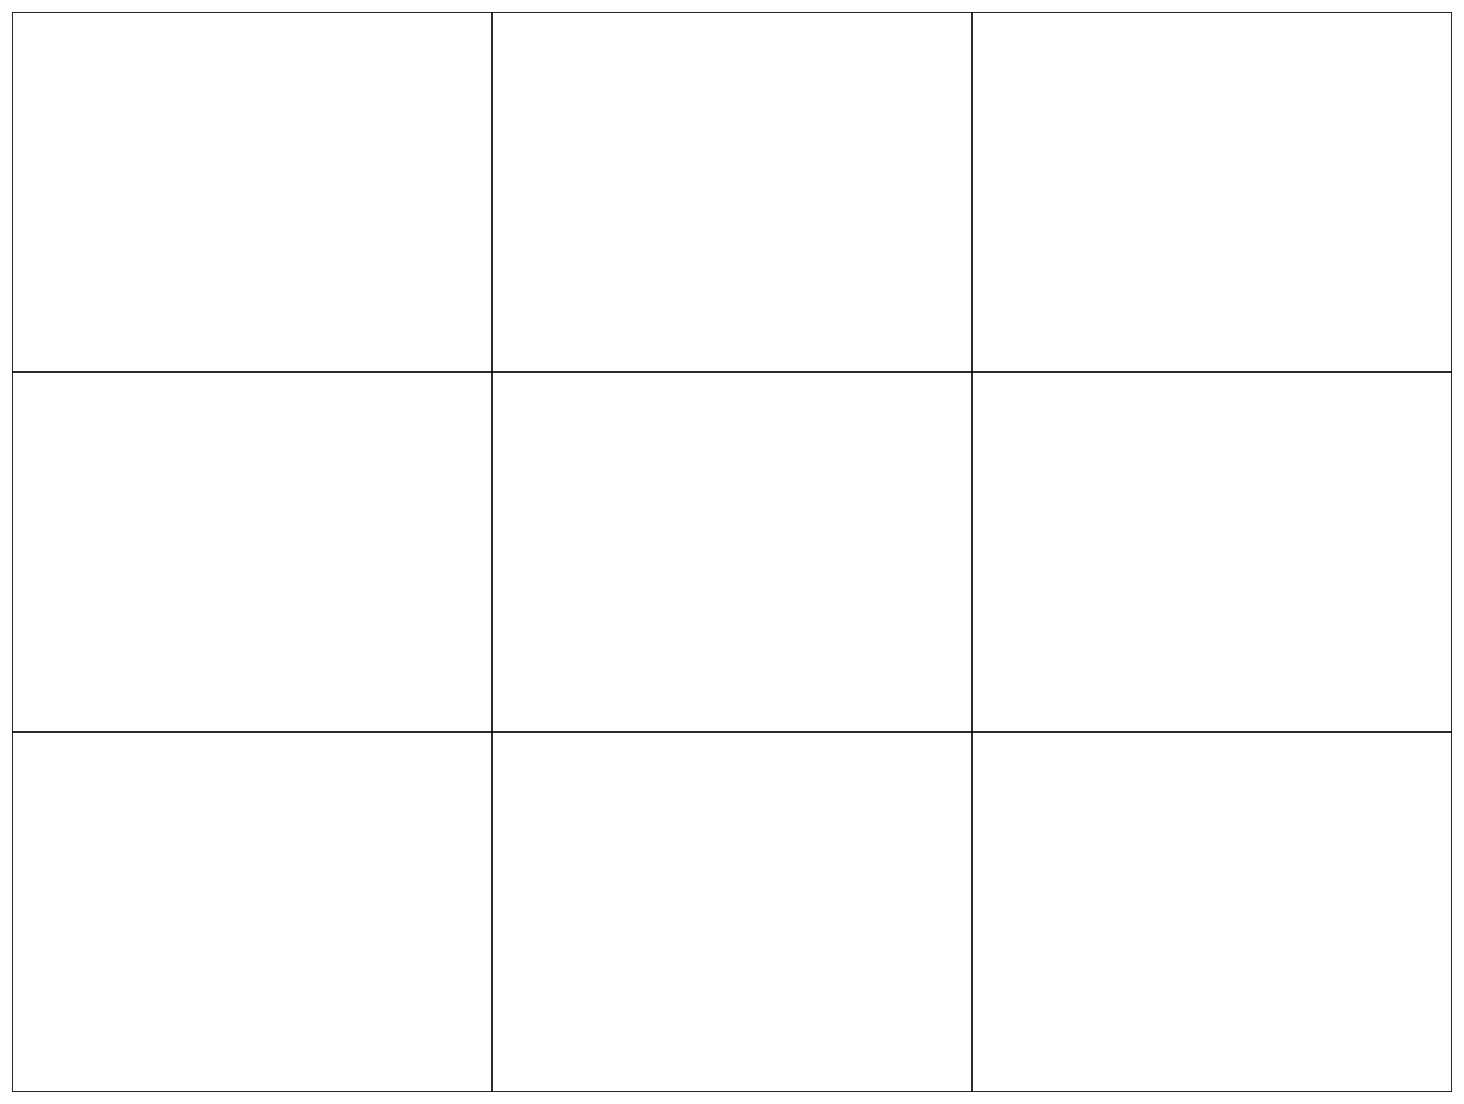

In [5]:
import matplotlib.pyplot as plt

# True 4:3 drawing area (4 wide, 3 tall) with a 3x3 grid.
fig, ax = plt.subplots(figsize=(12, 9), dpi=120)
ax.set_xlim(0, 4)
ax.set_ylim(0, 3)

# White background, no axes.
ax.set_facecolor("white")
ax.axis("off")

# Draw full 3x3 grid over the 4x3 canvas.
for x in [0, 4 / 3, 8 / 3, 4]:
    ax.plot([x, x], [0, 3], color="black", linewidth=1.0)
for y in [0, 1, 2, 3]:
    ax.plot([0, 4], [y, y], color="black", linewidth=1.0)

plt.tight_layout(pad=0)
plt.show()
